In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('data/train_test_dataset.csv', 
                 on_bad_lines='skip',  # Skip problematic lines
                 engine='python',
                 delimiter= ";")      # Use Python engine (more forgiving)

df.head()

,ref,subType,brand,itemDescriptionEN,itemCapacity,itemCapacityUnits,packType,nameEN,hsCodeNav,weightConfirmed,dimensionsConfirmed,weight,width,height,depth
0,000012SE,1,SE,Daeses Firming Body Milk,200,2,0,Firming Care,33049900,1,1,261,8,17,5
1,000010SE,1,SE,Daeses Firming Mask,75,2,0,Anti-Ageing Masks,33049900,1,1,112,4,17,4
2,000014SE,1,SE,Hidraderm Hyal Moisturizing Body Milk,400,2,0,Dryness & Dehydration,33049900,1,1,452,8,22,5
3,000015SE,1,SE,Hidraderm Cleansing Milk,200,2,0,Sensitive Skin,33049900,1,1,261,8,17,5
4,000019SE,1,SE,Hidraloe Aloe Vera Gel,250,2,0,Dryness & Dehydration,33049900,1,1,301,6,18,6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21852 entries, 0 to 21851
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ref                  21852 non-null  object
 1   subType              21852 non-null  int64 
 2   brand                21850 non-null  object
 3   itemDescriptionEN    21852 non-null  object
 4   itemCapacity         21852 non-null  object
 5   itemCapacityUnits    21852 non-null  int64 
 6   packType             21852 non-null  int64 
 7   nameEN               21852 non-null  object
 8   hsCodeNav            21852 non-null  int64 
 9   weightConfirmed      21852 non-null  int64 
 10  dimensionsConfirmed  21852 non-null  int64 
 11  weight               21852 non-null  int64 
 12  width                21852 non-null  int64 
 13  height               21852 non-null  int64 
 14  depth                21852 non-null  int64 
dtypes: int64(10), object(5)
memory usage: 2.5+ MB


In [4]:
df.describe()

,subType,itemCapacityUnits,packType,hsCodeNav,weightConfirmed,dimensionsConfirmed,weight,width,height,depth
count,21852.000000,21852.000000,21852.000000,2.185200e+04,21852.0,21852.0,21852.000000,21852.000000,21852.000000,21852.000000
mean,2.988514,2.342989,0.504439,3.420029e+07,1.0,1.0,200.187580,7.079947,13.423348,4.701309
std,5.541379,1.485831,2.076613,9.754281e+06,0.0,0.0,246.967441,4.715907,5.182817,2.664731
min,1.000000,0.000000,0.000000,2.106102e+07,1.0,1.0,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,0.000000,3.304200e+07,1.0,1.0,56.000000,4.000000,10.000000,3.000000
50%,1.000000,2.000000,0.000000,3.304990e+07,1.0,1.0,134.000000,6.000000,13.000000,4.000000
75%,3.000000,2.000000,0.000000,3.304990e+07,1.0,1.0,255.000000,8.000000,17.000000,6.000000
max,91.000000,14.000000,16.000000,9.619009e+07,1.0,1.0,5300.000000,140.000000,165.000000,56.000000


In [5]:
# Create a copy of your dataframe
df_encoded = df.copy()

# Columns to encode
columns_to_encode = ['brand', 'nameEN', 'hsCodeNav']

# Create label encoders for each column
label_encoders = {}

for column in columns_to_encode:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le  # Store encoder for future use

df_encoded.head()

,ref,subType,brand,itemDescriptionEN,itemCapacity,itemCapacityUnits,packType,nameEN,hsCodeNav,weightConfirmed,dimensionsConfirmed,weight,width,height,depth
0,000012SE,1,436,Daeses Firming Body Milk,200,2,0,78,7,1,1,261,8,17,5
1,000010SE,1,436,Daeses Firming Mask,75,2,0,9,7,1,1,112,4,17,4
2,000014SE,1,436,Hidraderm Hyal Moisturizing Body Milk,400,2,0,58,7,1,1,452,8,22,5
3,000015SE,1,436,Hidraderm Cleansing Milk,200,2,0,140,7,1,1,261,8,17,5
4,000019SE,1,436,Hidraloe Aloe Vera Gel,250,2,0,58,7,1,1,301,6,18,6


In [6]:
df_encoded.describe()

,subType,brand,itemCapacityUnits,packType,nameEN,hsCodeNav,weightConfirmed,dimensionsConfirmed,weight,width,height,depth
count,21852.000000,21852.000000,21852.000000,21852.000000,21852.000000,21852.000000,21852.0,21852.0,21852.000000,21852.000000,21852.000000,21852.000000
mean,2.988514,299.041461,2.342989,0.504439,84.989795,7.266978,1.0,1.0,200.187580,7.079947,13.423348,4.701309
std,5.541379,180.390472,1.485831,2.076613,43.138346,5.158618,0.0,0.0,246.967441,4.715907,5.182817,2.664731
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.000000,1.000000,1.000000,1.000000
25%,1.000000,129.000000,2.000000,0.000000,58.000000,4.000000,1.0,1.0,56.000000,4.000000,10.000000,3.000000
50%,1.000000,287.000000,2.000000,0.000000,85.000000,7.000000,1.0,1.0,134.000000,6.000000,13.000000,4.000000
75%,3.000000,452.000000,2.000000,0.000000,116.000000,7.000000,1.0,1.0,255.000000,8.000000,17.000000,6.000000
max,91.000000,617.000000,14.000000,16.000000,174.000000,30.000000,1.0,1.0,5300.000000,140.000000,165.000000,56.000000


In [8]:
# First, let's see how many rows have invalid values
original_shape = df_encoded.shape[0]

# Convert to numeric, invalid values become NaN
df_encoded['itemCapacity'] = pd.to_numeric(df_encoded['itemCapacity'], errors='coerce')

# Check how many NaN values we have
nan_count = df_encoded['itemCapacity'].isnull().sum()
print(f"Rows with invalid itemCapacity values: {nan_count}")
print(f"Original rows: {original_shape}")
print(f"Rows after dropping: {original_shape - nan_count}")

# Drop rows where itemCapacity is NaN
df_encoded = df_encoded.dropna(subset=['itemCapacity'])

# Convert to integer
df_encoded['itemCapacity'] = df_encoded['itemCapacity'].astype(int)

print(f"Final shape: {df_encoded.shape}")
print(f"Data type: {df_encoded['itemCapacity'].dtype}")

Rows with invalid itemCapacity values: 1789
Original rows: 21852
Rows after dropping: 20063
Final shape: (20063, 12)
Data type: int64


In [9]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20063 entries, 0 to 21851
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ref                20063 non-null  object
 1   subType            20063 non-null  int64 
 2   brand              20063 non-null  int64 
 3   itemCapacity       20063 non-null  int64 
 4   itemCapacityUnits  20063 non-null  int64 
 5   packType           20063 non-null  int64 
 6   nameEN             20063 non-null  int64 
 7   hsCodeNav          20063 non-null  int64 
 8   weight             20063 non-null  int64 
 9   width              20063 non-null  int64 
 10  height             20063 non-null  int64 
 11  depth              20063 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 2.0+ MB




## Random Forest Multi-Output Regression Pipeline with Adjustable Complexity

### COMPLEXITY REDUCTION OPTIONS:
1. COMPLEXITY_LEVEL: 
   - "minimal": 9 combinations, 3-fold CV (~27 fits) - FASTEST
   - "light": 36 combinations, 3-fold CV (~108 fits) - BALANCED  
   - "full": 540 combinations, 5-fold CV (~2700 fits) - COMPREHENSIVE

2. SAMPLE_SIZE: Set to integer (e.g., 5000) to limit dataset size

3. n_jobs: Set to 1 for single-core processing if memory is limited

Estimated training times:
- Minimal: 1-5 minutes
- Light: 5-20 minutes  
- Full: 30+ minutes (depends on dataset size)
"""

In [32]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Try to import optional models
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

In [33]:
# 1. Data Preparation
# Assuming your dataframe is df_encoded and contains all the processed columns

# Define features and targets
features = ['subType', 'brand', 'itemCapacity', 'itemCapacityUnits', 'packType', 'nameEN', 'hsCodeNav']
targets = ['weight', 'width', 'height', 'depth']

# Remove rows with missing values in target variables
df_clean = df_encoded.dropna(subset=targets + features)

# OPTIONAL: Sample data to reduce training time
SAMPLE_SIZE = 4000 #None  # Set to integer (e.g., 5000) to limit dataset size, or None for full dataset

if SAMPLE_SIZE and len(df_clean) > SAMPLE_SIZE:
    df_clean = df_clean.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"📊 Dataset sampled to {SAMPLE_SIZE} rows for faster training")

# Separate features and targets
X = df_clean[features]
y = df_clean[targets]

print(f"Dataset shape: {df_clean.shape}")
print(f"Features shape: {X.shape}")
print(f"Targets shape: {y.shape}")
print(f"Missing values in features: {X.isnull().sum().sum()}")
print(f"Missing values in targets: {y.isnull().sum().sum()}")

📊 Dataset sampled to 4000 rows for faster training
Dataset shape: (4000, 12)
Features shape: (4000, 7)
Targets shape: (4000, 4)
Missing values in features: 0
Missing values in targets: 0


In [34]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 3200 samples
Test set: 800 samples


In [35]:
# 3. Model Configuration

# Choose complexity level
COMPLEXITY_LEVEL = "minimal"  # Options: "minimal", "light", "full"

# Choose which models to test
MODELS_TO_TEST = [
    "random_forest",
    #"gradient_boosting", 
    #"xgboost",     # Uncomment if you have xgboost installed
    #"lightgbm",    # Uncomment if you have lightgbm installed
    # "extra_trees"  # Uncomment to test Extra Trees
]

print(f"🤖 Models to test: {', '.join(MODELS_TO_TEST)}")

🤖 Models to test: random_forest


In [36]:
# 4. Define Models and Parameter Grids

def get_models_and_params(complexity_level):
    """Get models and their parameter grids based on complexity level"""
    
    models = {}
    param_grids = {}
    
    # Set CV folds based on complexity
    if complexity_level == "minimal":
        cv_folds = 3
    elif complexity_level == "light":
        cv_folds = 3
    else:
        cv_folds = 5
    
    # Random Forest
    models['random_forest'] = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', MultiOutputRegressor(RandomForestRegressor(random_state=42, n_jobs=-1)))
    ])
    
    if complexity_level == "minimal":
        param_grids['random_forest'] = {
            'regressor__estimator__n_estimators': [50, 100],
            'regressor__estimator__max_depth': [10, None],
            'regressor__estimator__min_samples_split': [2],
            'regressor__estimator__max_features': ['sqrt']
        }
    elif complexity_level == "light":
        param_grids['random_forest'] = {
            'regressor__estimator__n_estimators': [50, 100],
            'regressor__estimator__max_depth': [10, 20, None],
            'regressor__estimator__min_samples_split': [2, 5],
            'regressor__estimator__max_features': ['sqrt', 'log2']
        }
    else:  # full
        param_grids['random_forest'] = {
            'regressor__estimator__n_estimators': [50, 100, 200],
            'regressor__estimator__max_depth': [None, 10, 20, 30],
            'regressor__estimator__min_samples_split': [2, 5, 10],
            'regressor__estimator__min_samples_leaf': [1, 2, 4],
            'regressor__estimator__max_features': ['sqrt', 'log2', None]
        }
    
    # Gradient Boosting
    models['gradient_boosting'] = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', MultiOutputRegressor(GradientBoostingRegressor(random_state=42)))
    ])
    
    if complexity_level == "minimal":
        param_grids['gradient_boosting'] = {
            'regressor__estimator__n_estimators': [50, 100],
            'regressor__estimator__learning_rate': [0.1],
            'regressor__estimator__max_depth': [3, 5]
        }
    elif complexity_level == "light":
        param_grids['gradient_boosting'] = {
            'regressor__estimator__n_estimators': [50, 100],
            'regressor__estimator__learning_rate': [0.1, 0.2],
            'regressor__estimator__max_depth': [3, 5, 7],
            'regressor__estimator__subsample': [0.8, 1.0]
        }
    else:  # full
        param_grids['gradient_boosting'] = {
            'regressor__estimator__n_estimators': [50, 100, 200],
            'regressor__estimator__learning_rate': [0.05, 0.1, 0.2],
            'regressor__estimator__max_depth': [3, 5, 7],
            'regressor__estimator__subsample': [0.8, 0.9, 1.0],
            'regressor__estimator__min_samples_split': [2, 5]
        }
    
    # Extra Trees
    models['extra_trees'] = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', MultiOutputRegressor(ExtraTreesRegressor(random_state=42, n_jobs=-1)))
    ])
    
    if complexity_level == "minimal":
        param_grids['extra_trees'] = {
            'regressor__estimator__n_estimators': [50, 100],
            'regressor__estimator__max_depth': [10, None],
            'regressor__estimator__min_samples_split': [2]
        }
    else:
        param_grids['extra_trees'] = param_grids['random_forest']  # Same as RF for simplicity
    
    # XGBoost
    if XGBOOST_AVAILABLE:
        models['xgboost'] = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', MultiOutputRegressor(xgb.XGBRegressor(random_state=42, n_jobs=-1)))
        ])
        
        if complexity_level == "minimal":
            param_grids['xgboost'] = {
                'regressor__estimator__n_estimators': [50, 100],
                'regressor__estimator__learning_rate': [0.1],
                'regressor__estimator__max_depth': [3, 6]
            }
        elif complexity_level == "light":
            param_grids['xgboost'] = {
                'regressor__estimator__n_estimators': [50, 100],
                'regressor__estimator__learning_rate': [0.1, 0.2],
                'regressor__estimator__max_depth': [3, 6, 9],
                'regressor__estimator__subsample': [0.8, 1.0]
            }
        else:  # full
            param_grids['xgboost'] = {
                'regressor__estimator__n_estimators': [50, 100, 200],
                'regressor__estimator__learning_rate': [0.05, 0.1, 0.2],
                'regressor__estimator__max_depth': [3, 6, 9],
                'regressor__estimator__subsample': [0.8, 0.9, 1.0],
                'regressor__estimator__colsample_bytree': [0.8, 1.0]
            }
    
    # LightGBM
    if LIGHTGBM_AVAILABLE:
        models['lightgbm'] = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', MultiOutputRegressor(lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)))
        ])
        
        if complexity_level == "minimal":
            param_grids['lightgbm'] = {
                'regressor__estimator__n_estimators': [50, 100],
                'regressor__estimator__learning_rate': [0.1],
                'regressor__estimator__max_depth': [3, 6]
            }
        else:
            param_grids['lightgbm'] = param_grids.get('xgboost', param_grids['gradient_boosting'])
    
    return models, param_grids, cv_folds

# Get models and parameters
available_models, param_grids, cv_folds = get_models_and_params(COMPLEXITY_LEVEL)

# Filter models to test
models_to_run = {name: available_models[name] for name in MODELS_TO_TEST if name in available_models}
params_to_run = {name: param_grids[name] for name in MODELS_TO_TEST if name in param_grids}

print(f"🔧 Complexity level: {COMPLEXITY_LEVEL.upper()}")
print(f"📊 Cross-validation folds: {cv_folds}")

🔧 Complexity level: MINIMAL
📊 Cross-validation folds: 3


In [37]:
# 5. Model Training with Progress Tracking

# Try to import tqdm for progress bars
try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    print("Install tqdm for progress bars: pip install tqdm")

results = {}
best_models = {}

for model_name in models_to_run:
    print(f"\n{'='*60}")
    print(f"🚀 Training {model_name.replace('_', ' ').title()}")
    print('='*60)
    
    model = models_to_run[model_name]
    param_grid = params_to_run[model_name]
    
    # Calculate total combinations
    total_combinations = np.prod([len(v) for v in param_grid.values()])
    total_fits = total_combinations * cv_folds
    
    print(f"Parameter combinations: {total_combinations}")
    print(f"Total fits: {total_fits}")
    
    # Grid Search
    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=cv_folds,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1 if not TQDM_AVAILABLE else 0,
        return_train_score=True
    )
    
    # Fit model
    print(f"⏱️  Training started...")
    grid_search.fit(X_train, y_train)
    print(f"✅ Training completed!")
    
    # Store results
    results[model_name] = {
        'grid_search': grid_search,
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'cv_rmse': np.sqrt(-grid_search.best_score_)
    }
    
    best_models[model_name] = grid_search.best_estimator_
    
    print(f"Best CV RMSE: {results[model_name]['cv_rmse']:.4f}")


🚀 Training Random Forest
Parameter combinations: 4
Total fits: 12
⏱️  Training started...
✅ Training completed!
Best CV RMSE: 79.5159


In [38]:
# 6. Model Comparison and Evaluation

print(f"\n{'='*60}")
print("📊 MODEL COMPARISON RESULTS")
print('='*60)

# Calculate test set metrics for all models
comparison_results = []

for model_name, model in best_models.items():
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)
    cv_rmse = results[model_name]['cv_rmse']
    
    comparison_results.append({
        'Model': model_name.replace('_', ' ').title(),
        'CV_RMSE': cv_rmse,
        'Test_RMSE': test_rmse,
        'Test_MAE': test_mae,
        'Test_R²': test_r2
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values('Test_R²', ascending=False)

print(comparison_df.round(4))

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_model_key = best_model_name.lower().replace(' ', '_')
best_model = best_models[best_model_key]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test R²: {comparison_df.iloc[0]['Test_R²']:.4f}")
print(f"   Test RMSE: {comparison_df.iloc[0]['Test_RMSE']:.4f}")


📊 MODEL COMPARISON RESULTS
           Model  CV_RMSE  Test_RMSE  Test_MAE  Test_R²
0  Random Forest  79.5159    76.4661    16.383   0.6071

🏆 BEST MODEL: Random Forest
   Test R²: 0.6071
   Test RMSE: 76.4661


In [39]:
# 7. Detailed Analysis for Best Model

print(f"\n{'='*60}")
print(f"📈 DETAILED ANALYSIS - {best_model_name}")
print('='*60)

# Best model predictions
y_pred_best = best_model.predict(X_test)

# Calculate metrics for each target
def calculate_metrics_by_target(y_true, y_pred, target_names):
    metrics_df = pd.DataFrame(index=target_names)
    
    for i, target in enumerate(target_names):
        mse = mean_squared_error(y_true.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2 = r2_score(y_true.iloc[:, i], y_pred[:, i])
        
        metrics_df.loc[target, 'MSE'] = mse
        metrics_df.loc[target, 'RMSE'] = rmse
        metrics_df.loc[target, 'MAE'] = mae
        metrics_df.loc[target, 'R²'] = r2
    
    return metrics_df

metrics_by_target = calculate_metrics_by_target(y_test, y_pred_best, targets)
print("\nMetrics by Target Variable:")
print(metrics_by_target.round(4))


📈 DETAILED ANALYSIS - Random Forest

Metrics by Target Variable:
               MSE      RMSE      MAE      R²
weight  23363.0284  152.8497  60.0006  0.7163
width       7.6221    2.7608   1.7240  0.6533
height     14.4631    3.8030   2.6866  0.5166
depth       3.1256    1.7679   1.1209  0.5424


In [40]:
# 8. Feature Importance (if available)
if hasattr(best_model.named_steps['regressor'], 'estimators_'):
    print(f"\n📊 FEATURE IMPORTANCE - {best_model_name}")
    
    try:
        feature_importances = []
        for i, target in enumerate(targets):
            estimator = best_model.named_steps['regressor'].estimators_[i]
            if hasattr(estimator, 'feature_importances_'):
                feature_importances.append(estimator.feature_importances_)
            else:
                feature_importances.append([0] * len(features))  # Fallback
        
        importance_df = pd.DataFrame(
            feature_importances,
            index=targets,
            columns=features
        ).T
        
        print(importance_df.round(4))
    except Exception as e:
        print(f"Could not extract feature importance: {e}")


📊 FEATURE IMPORTANCE - Random Forest
                   weight   width  height   depth
subType            0.0840  0.0786  0.0712  0.0869
brand              0.1554  0.1877  0.2093  0.2605
itemCapacity       0.3386  0.1830  0.3232  0.2409
itemCapacityUnits  0.0520  0.1641  0.0962  0.0507
packType           0.0680  0.1048  0.0251  0.0422
nameEN             0.1089  0.1372  0.1523  0.1631
hsCodeNav          0.1932  0.1446  0.1228  0.1557



📊 Generating visualizations...


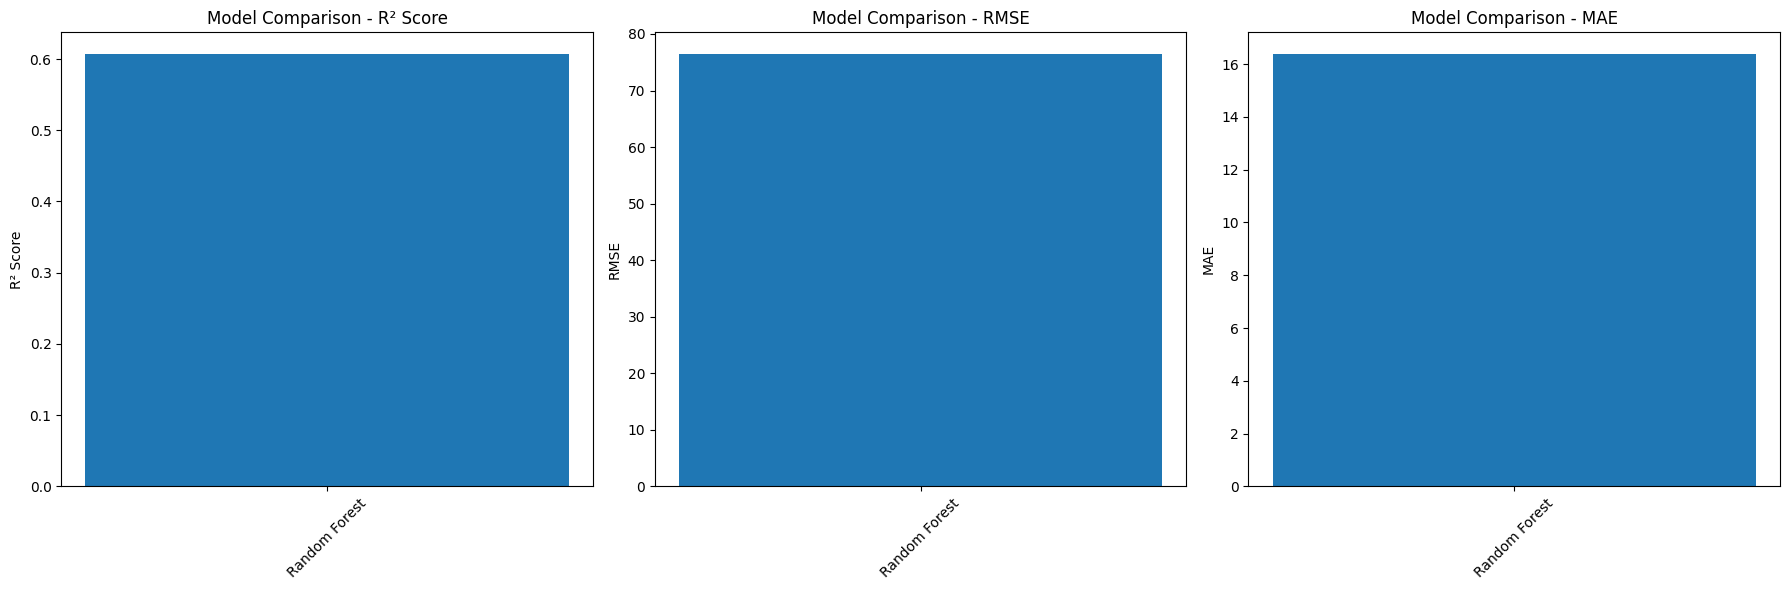

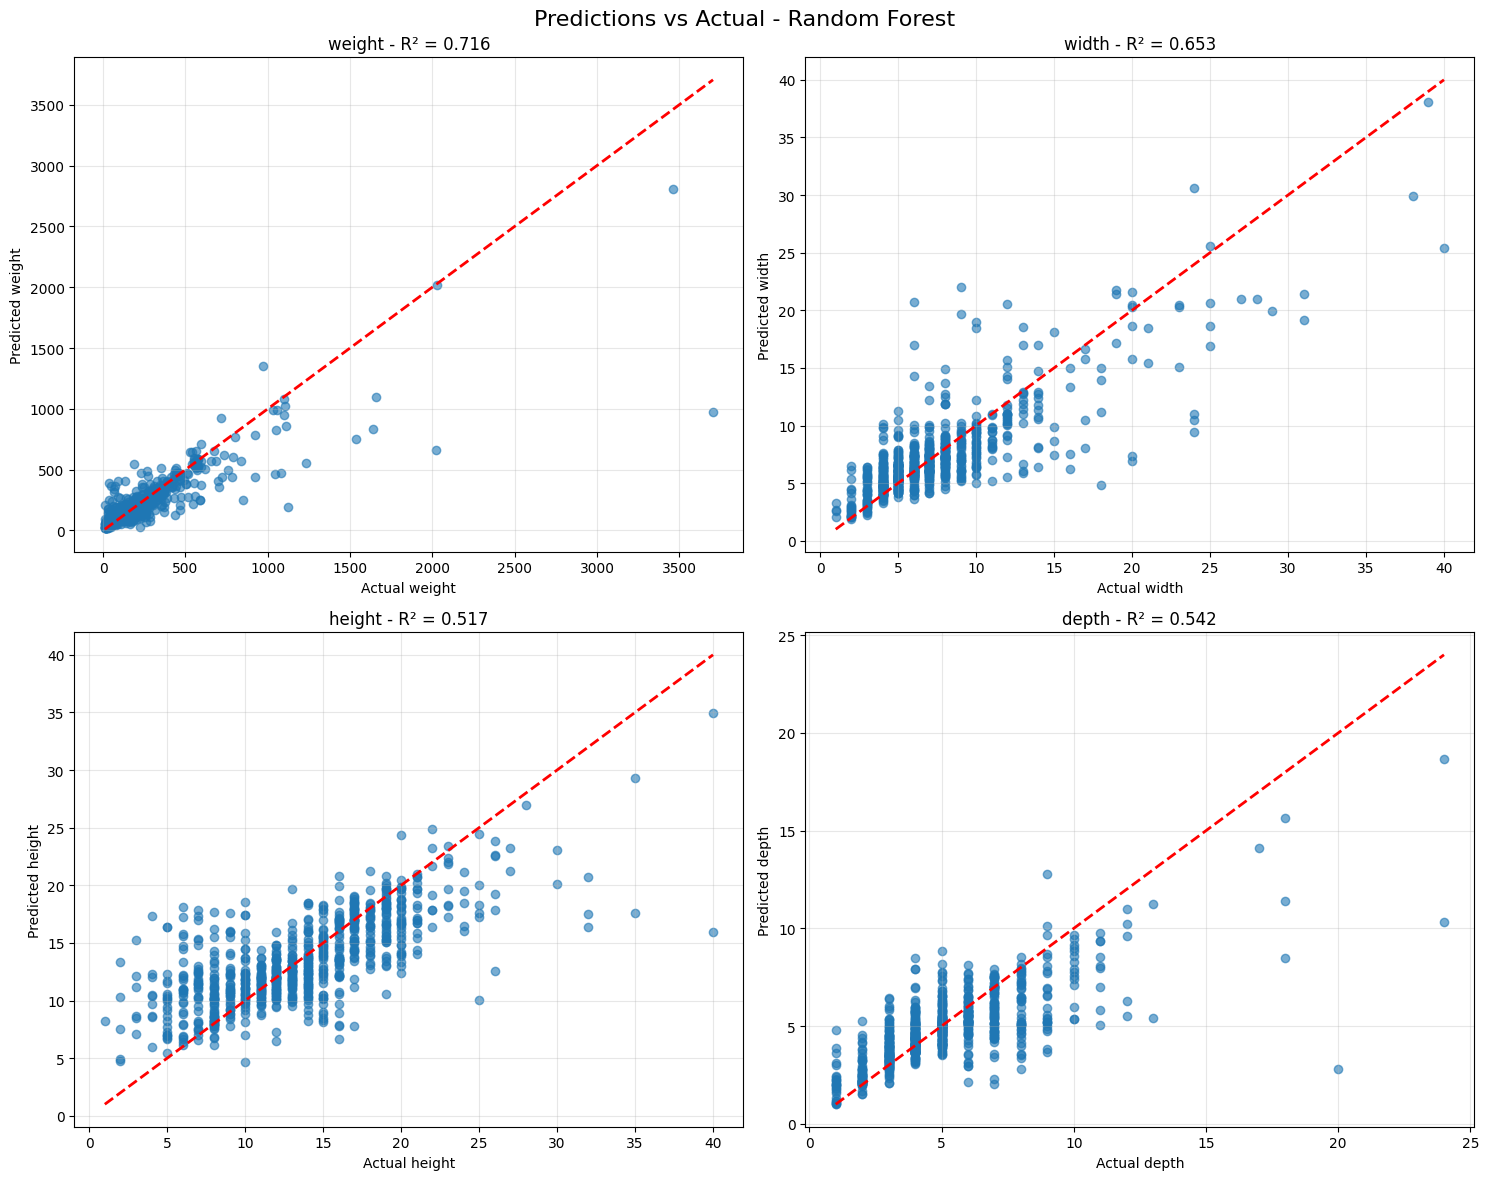

In [41]:
# 9. Visualization
def plot_model_comparison(comparison_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # R² comparison
    axes[0].bar(comparison_df['Model'], comparison_df['Test_R²'])
    axes[0].set_title('Model Comparison - R² Score')
    axes[0].set_ylabel('R² Score')
    axes[0].tick_params(axis='x', rotation=45)
    
    # RMSE comparison
    axes[1].bar(comparison_df['Model'], comparison_df['Test_RMSE'])
    axes[1].set_title('Model Comparison - RMSE')
    axes[1].set_ylabel('RMSE')
    axes[1].tick_params(axis='x', rotation=45)
    
    # MAE comparison
    axes[2].bar(comparison_df['Model'], comparison_df['Test_MAE'])
    axes[2].set_title('Model Comparison - MAE')
    axes[2].set_ylabel('MAE')
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

def plot_predictions_vs_actual(y_true, y_pred, target_names, model_name):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    for i, target in enumerate(target_names):
        axes[i].scatter(y_true.iloc[:, i], y_pred[:, i], alpha=0.6)
        axes[i].plot([y_true.iloc[:, i].min(), y_true.iloc[:, i].max()], 
                    [y_true.iloc[:, i].min(), y_true.iloc[:, i].max()], 'r--', lw=2)
        axes[i].set_xlabel(f'Actual {target}')
        axes[i].set_ylabel(f'Predicted {target}')
        axes[i].set_title(f'{target} - R² = {r2_score(y_true.iloc[:, i], y_pred[:, i]):.3f}')
        axes[i].grid(True, alpha=0.3)
    
    fig.suptitle(f'Predictions vs Actual - {model_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Generate plots
print("\n📊 Generating visualizations...")
plot_model_comparison(comparison_df)
plot_predictions_vs_actual(y_test, y_pred_best, targets, best_model_name)

In [42]:
# 10. Summary
print(f"\n{'='*60}")
print("🎯 FINAL SUMMARY")
print('='*60)
print(f"✅ Models tested: {len(comparison_results)}")
print(f"🏆 Best model: {best_model_name}")
print(f"📊 Best R² score: {comparison_df.iloc[0]['Test_R²']:.4f}")
print(f"🎯 Best RMSE: {comparison_df.iloc[0]['Test_RMSE']:.4f}")
print(f"🔧 Complexity level: {COMPLEXITY_LEVEL}")

# Save results (optional)
# comparison_df.to_csv('model_comparison_results.csv', index=False)
# metrics_by_target.to_csv('best_model_metrics_by_target.csv')

print(f"\n🚀 Multi-model pipeline completed successfully!")
print(f"The best model ({best_model_name}) is ready for predictions on new data.")


🎯 FINAL SUMMARY
✅ Models tested: 1
🏆 Best model: Random Forest
📊 Best R² score: 0.6071
🎯 Best RMSE: 76.4661
🔧 Complexity level: minimal

🚀 Multi-model pipeline completed successfully!
The best model (Random Forest) is ready for predictions on new data.
